# Chapter 04: The Intrinsic Geometry of Surfaces

Source orientation: do Carmo, *Differential Geometry of Curves and Surfaces*, Chapter 4, printed pp. 220-320 / PDF pp. 236-336. This notebook is an original visualization-first reconstruction of the chapter's route; it does not reproduce textbook prose, figures, screenshots, exercise text, hints, or answers.

## Chapter Goal

The chapter asks which surface facts can be recovered from measurements made inside the surface. By the end, the metric should feel like executable data: it determines Christoffel symbols, geodesic equations, parallel transport, Gaussian curvature, geodesic polar coordinates, and the curvature/topology balance in Gauss-Bonnet.


## Computational Translation Guide

| Book object | Computational representation | What we check |
| --- | --- | --- |
| First fundamental form | A symmetric metric matrix `g(u, v)` | positive determinant, lengths, angles, area scale |
| Isometry | Pullback equation `J.T @ g_target @ J = g_source` | cylinder unrolling has the same metric as the plane |
| Conformal map | Pullback equation `J.T @ J = lambda I` | right angles survive while scale varies |
| Christoffel symbols | derivatives of `g` and `g^{-1}` | symbolic sphere values and `K = 1/R^2` |
| Compatibility | Gauss and Mainardi-Codazzi equations | proof-state graph plus symbolic Gauss equation sample |
| Geodesic | second-order ODE from Christoffel symbols | speed conservation and great-circle residual |
| Parallel transport | first-order ODE along a curve | length conservation and holonomy/area agreement |
| Gauss-Bonnet | curvature, boundary turning, corner angles, Euler characteristic | spherical triangle excess and mesh Euler ledgers |
| Exponential coordinates | geodesics emitted from one tangent plane | `S_K'' + K S_K = 0` spreading law |

Library routing: SymPy is used for exact metric identities; SciPy solves the geodesic and transport ODEs; Plotly exposes a rotatable 3D sphere/geodesic scene; Matplotlib and NetworkX build durable static diagrams and proof-state ledgers; Trimesh supplies a mesh-level Euler characteristic check for the global Gauss-Bonnet term.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = []
    for base in [start, *start.parents]:
        candidates.append(base)
        candidates.append(base / "Differential-Geometry-of-Curves-and-Surfaces")
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate the course root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

UNIT = "chapter-04"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"BOOK_ROOT detected: {BOOK_ROOT.name}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()}")


BOOK_ROOT detected: Differential-Geometry-of-Curves-and-Surfaces
ARTIFACT_ROOT = artifacts/chapter-04


## Route Through The Chapter

1. Start with the metric as the intrinsic measuring device.
2. Separate an isometry from a conformal map by looking at grids and pullback matrices.
3. Compute Christoffel symbols and Gaussian curvature directly from the metric.
4. Use the same Christoffel symbols to run geodesic and parallel-transport ODEs.
5. Read Gauss-Bonnet as a ledger tying curvature, turning, corners, and topology.
6. Use the exponential map to make geodesic normal and polar coordinates visible.

The source chapter also includes the local-theory appendix: prescribed first and second fundamental forms do not come from a surface until the compatibility equations are satisfied. In this notebook that idea appears as a proof graph and as symbolic checks rather than as a copied proof.


## Visual Storyboard

| Artifact | Concept | Representation | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| `isometry-conformal-metric-tests.png` | intrinsic metric data versus embedding and conformal scale | grid diagrams plus metric pullback tests | compare preserved lengths on the cylinder with preserved angles under an analytic map | pullback residuals |
| `christoffel-compatibility-proof-graph.png` | Christoffel symbols and Gauss-Codazzi compatibility | NetworkX dependency graph plus formula labels | follow which data determine the connection and which equations constrain a surface | symbolic sphere curvature |
| `sphere-geodesic-ode-and-transport.png` | geodesic and parallel transport ODEs | 3D/2D diagnostic panels | speed stays constant, geodesic remains in a fixed plane, transport returns rotated | ODE residuals and holonomy |
| `sphere-geodesic-flow-and-holonomy.html` | same ODE data in a rotatable surface view | Plotly 3D sphere with paths/vectors | rotate the sphere and inspect the geodesic fan and latitude loop | same JSON ledger |
| `gauss-bonnet-exponential-coordinates.png` | local/global Gauss-Bonnet and exponential polar spreading | triangle, topology bars, and `S_K(r)` curves | angle excess equals curvature area; `S_K` shows geodesic separation | angle excess, Euler characteristic, ODE residual |


## Intrinsic Versus Extrinsic Data

A surface can be bent in space without changing every measurement available to a resident of the surface. A plane strip and a cylinder patch are the basic test: the picture in `R^3` changes, but the metric in coordinates `(u, v)` remains `du^2 + dv^2`. That is an intrinsic equality.

A conformal map is weaker. It keeps tangent directions orthogonal when they were orthogonal, but it may change the scale from point to point. In computation this difference is visible in a pullback matrix. Isometry asks for the exact metric matrix; conformality asks for a scalar multiple of it.


In [2]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def analytic_map(z):
    return z + 0.22 * z**2


def analytic_jacobian(x, y):
    a = 0.22
    ux = 1 + 2 * a * x
    uy = -2 * a * y
    vx = 2 * a * y
    vy = 1 + 2 * a * x
    return np.array([[ux, uy], [vx, vy]], dtype=float)

# Isometry check: plane (u, v) -> cylinder (cos u, sin u, v).
samples = np.array([[-1.2, -0.6], [0.0, 0.0], [1.1, 0.75], [2.0, -0.25]])
metric_plane = np.eye(2)
metric_cyl_pullbacks = []
for u, v in samples:
    xu = np.array([-math.sin(u), math.cos(u), 0.0])
    xv = np.array([0.0, 0.0, 1.0])
    metric_cyl_pullbacks.append(np.array([[xu @ xu, xu @ xv], [xv @ xu, xv @ xv]]))
isometry_residual = max(float(np.linalg.norm(g - metric_plane, ord=np.inf)) for g in metric_cyl_pullbacks)

# Conformal check for the analytic grid map.
conformal_residuals = []
conformal_scales = []
for x, y in samples:
    J = analytic_jacobian(x, y)
    pull = J.T @ J
    scale = float(np.trace(pull) / 2.0)
    conformal_scales.append(scale)
    conformal_residuals.append(float(np.linalg.norm(pull - scale * np.eye(2), ord=np.inf)))
conformal_residual = max(conformal_residuals)
scale_range = [float(min(conformal_scales)), float(max(conformal_scales))]

fig = plt.figure(figsize=(13.5, 4.6), constrained_layout=True)
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2, projection="3d")
ax2 = fig.add_subplot(1, 3, 3)

grid_values = np.linspace(-1.4, 1.4, 9)
t = np.linspace(-1.4, 1.4, 220)
for c in grid_values:
    ax0.plot(t, np.full_like(t, c), color="#1f77b4", lw=0.9)
    ax0.plot(np.full_like(t, c), t, color="#1f77b4", lw=0.9)
ax0.set_title("Plane metric: du^2 + dv^2")
ax0.set_aspect("equal")
ax0.set_xticks([])
ax0.set_yticks([])
ax0.text(-1.35, 1.55, "lengths and right angles are read in coordinates", fontsize=9)

u = np.linspace(-1.4, 1.4, 220)
v = np.linspace(-1.4, 1.4, 220)
for c in grid_values:
    ax1.plot(np.cos(u), np.sin(u), np.full_like(u, c), color="#1f77b4", lw=0.9)
    ax1.plot(np.full_like(v, np.cos(c)), np.full_like(v, np.sin(c)), v, color="#1f77b4", lw=0.9)
ax1.set_title("Rolled patch: same metric")
ax1.set_box_aspect((1, 1, 1.35))
ax1.set_axis_off()
ax1.view_init(elev=21, azim=-52)

for c in grid_values:
    w1 = analytic_map(t + 1j * c)
    w2 = analytic_map(c + 1j * t)
    ax2.plot(w1.real, w1.imag, color="#b23a48", lw=0.9)
    ax2.plot(w2.real, w2.imag, color="#2a9d8f", lw=0.9)
ax2.set_aspect("equal")
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title("Conformal map: angles yes, scale varies")
ax2.text(-1.55, 1.75, f"scale range on samples: {scale_range[0]:.2f} to {scale_range[1]:.2f}", fontsize=9)

metric_fig_path = FIG_DIR / "isometry-conformal-metric-tests.png"
fig.savefig(metric_fig_path, dpi=170, bbox_inches="tight")
plt.close(fig)

metric_checks = {
    "cylinder_plane_isometry_pullback_inf_norm": isometry_residual,
    "analytic_conformal_pullback_inf_norm": conformal_residual,
    "analytic_conformal_sample_scale_range": scale_range,
}
metric_checks


{'cylinder_plane_isometry_pullback_inf_norm': 0.0,
 'analytic_conformal_pullback_inf_norm': 4.495737115917109e-16,
 'analytic_conformal_sample_scale_range': [0.29247999999999996, 3.5465]}

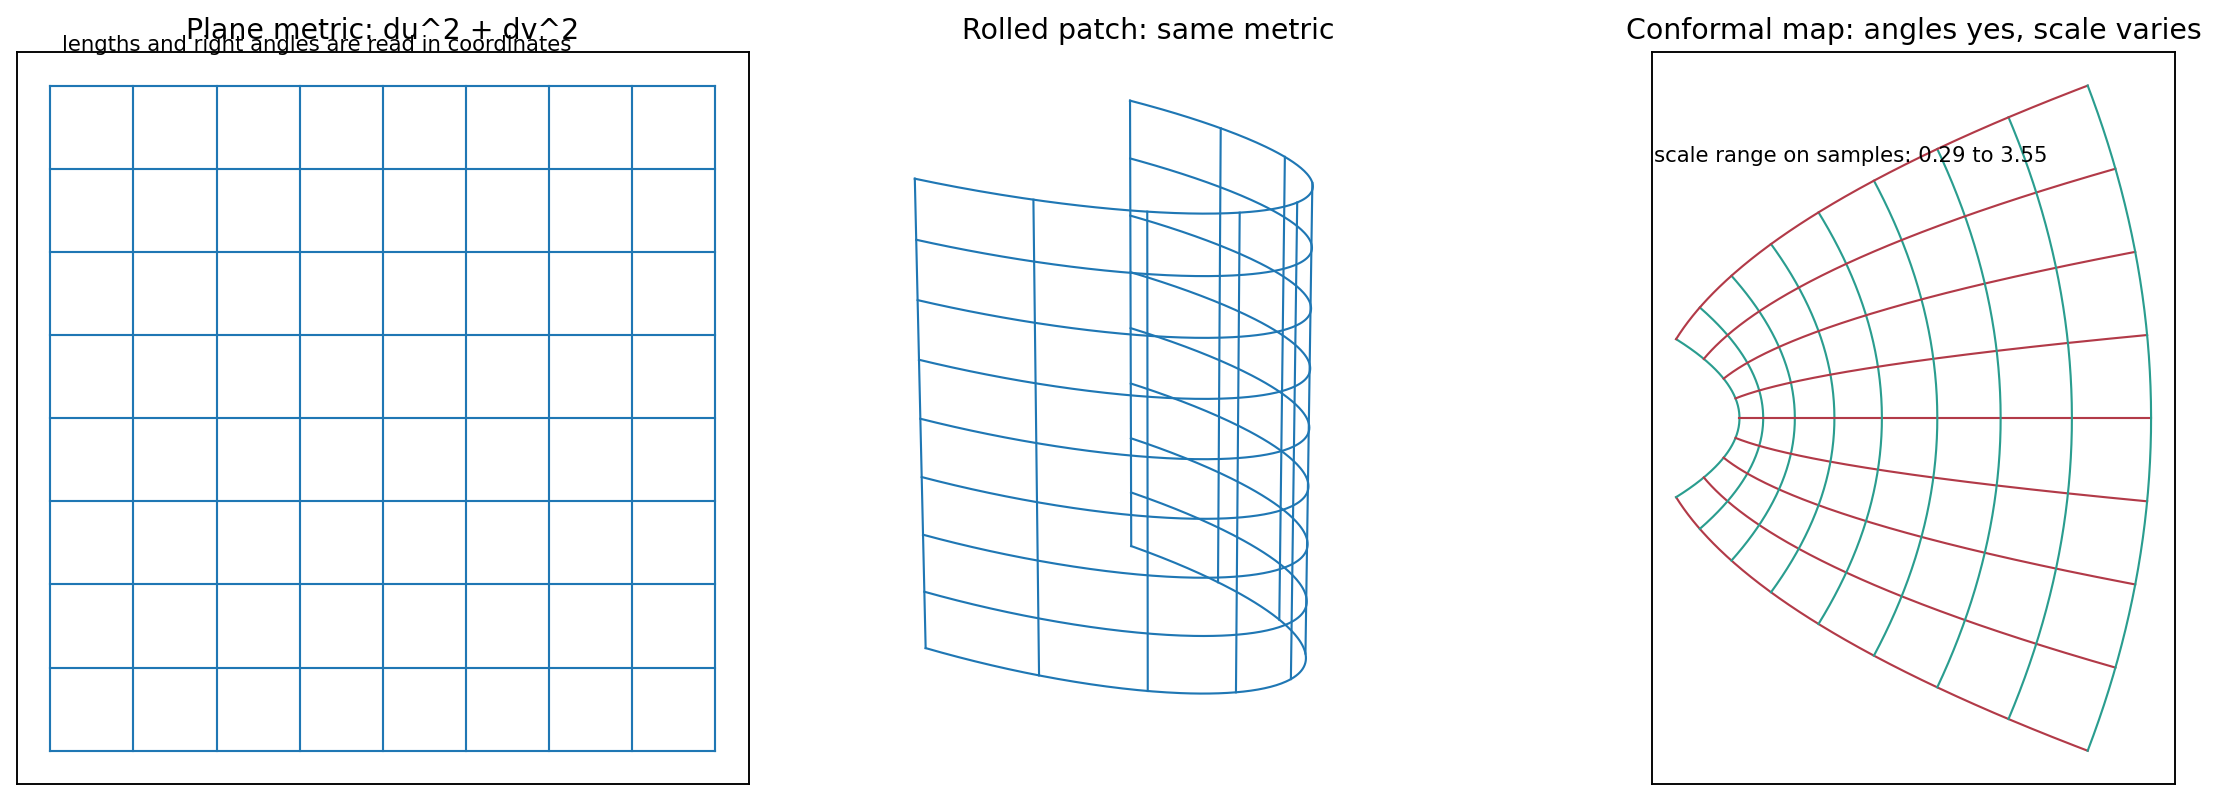

In [3]:
display_artifact(metric_fig_path, width=900)


The cylinder panel is deliberately extrinsic: it shows bending in `R^3`. The check is intrinsic: the pullback metric is exactly the identity. The conformal panel is the opposite warning. The grid still crosses orthogonally, but the scale factor is not constant, so it is not an isometry of the Euclidean metric.


## Christoffel Symbols From The Metric

The connection is the rule for differentiating tangent vector fields while staying tangent. In coordinates it is encoded by Christoffel symbols. Their important feature in this chapter is not the notation but the dependency: the first fundamental form and its first derivatives determine them.

The next cell computes the sphere connection and curvature from the metric alone. No normal vector or second fundamental form enters the calculation. This is the computational version of the chapter's intrinsic curvature message.


In [4]:
import sympy as sp

th, ph, R = sp.symbols("theta phi R", positive=True)
coords = (th, ph)
g = sp.Matrix([[R**2, 0], [0, R**2 * sp.sin(th)**2]])
g_inv = sp.simplify(g.inv())

Gamma = {}
for k in range(2):
    for i in range(2):
        for j in range(2):
            expr = sp.Rational(0)
            for ell in range(2):
                expr += g_inv[k, ell] * (
                    sp.diff(g[ell, j], coords[i])
                    + sp.diff(g[ell, i], coords[j])
                    - sp.diff(g[i, j], coords[ell])
                ) / 2
            Gamma[(k, i, j)] = sp.simplify(expr)

Riem = {}
for l in range(2):
    for i in range(2):
        for j in range(2):
            for k in range(2):
                expr = sp.diff(Gamma[(l, i, k)], coords[j]) - sp.diff(Gamma[(l, i, j)], coords[k])
                for m in range(2):
                    expr += Gamma[(m, i, k)] * Gamma[(l, m, j)] - Gamma[(m, i, j)] * Gamma[(l, m, k)]
                Riem[(l, i, j, k)] = sp.simplify(expr)

R_lower_theta_phi_theta_phi = sp.simplify(g[0, 0] * Riem[(0, 1, 0, 1)])
K_sphere = sp.simplify(R_lower_theta_phi_theta_phi / sp.det(g))

christoffel_rows = []
labels = {0: "theta", 1: "phi"}
for key, expr in Gamma.items():
    if expr != 0:
        k, i, j = key
        christoffel_rows.append({"symbol": f"Gamma^{labels[k]}_{labels[i]}{labels[j]}", "value": str(expr)})

christoffel_table_path = TABLE_DIR / "christoffel-symbols-sphere.csv"
with christoffel_table_path.open("w", newline="", encoding="utf-8") as fh:
    writer = csv.DictWriter(fh, fieldnames=["symbol", "value"])
    writer.writeheader()
    writer.writerows(christoffel_rows)

symbolic_checks = {
    "sphere_metric_det": str(sp.factor(sp.det(g))),
    "sphere_nonzero_christoffel_count": len(christoffel_rows),
    "sphere_gaussian_curvature_from_metric": str(K_sphere),
    "sphere_curvature_residual_vs_1_over_R2": str(sp.simplify(K_sphere - 1 / R**2)),
}
assert sp.simplify(K_sphere - 1 / R**2) == 0
symbolic_checks


{'sphere_metric_det': 'R**4*sin(theta)**2',
 'sphere_nonzero_christoffel_count': 3,
 'sphere_gaussian_curvature_from_metric': 'R**(-2)',
 'sphere_curvature_residual_vs_1_over_R2': '0'}

## Compatibility As A Proof-State Graph

Christoffel symbols are not an arbitrary decoration attached to coordinates. Once `E`, `F`, and `G` are fixed, the connection is fixed. If one also proposes coefficients `e`, `f`, and `g` for the second fundamental form, the Gauss and Mainardi-Codazzi equations are the compatibility gates. The local-theory appendix explains why these gates are not cosmetic: when the data pass the gates, a local surface exists and is unique up to a rigid motion.


In [5]:
import networkx as nx

Gproof = nx.DiGraph()
Gproof.add_nodes_from([
    ("metric g", {"kind": "data"}),
    ("first derivatives of g", {"kind": "data"}),
    ("Christoffel symbols", {"kind": "connection"}),
    ("geodesic ODE", {"kind": "motion"}),
    ("parallel transport ODE", {"kind": "motion"}),
    ("Riemann curvature", {"kind": "curvature"}),
    ("Gaussian curvature K", {"kind": "curvature"}),
    ("second form h", {"kind": "extrinsic data"}),
    ("Gauss equation", {"kind": "compatibility"}),
    ("Codazzi equations", {"kind": "compatibility"}),
    ("local surface up to rigid motion", {"kind": "existence"}),
])
Gproof.add_edges_from([
    ("metric g", "first derivatives of g"),
    ("metric g", "Christoffel symbols"),
    ("first derivatives of g", "Christoffel symbols"),
    ("Christoffel symbols", "geodesic ODE"),
    ("Christoffel symbols", "parallel transport ODE"),
    ("Christoffel symbols", "Riemann curvature"),
    ("Riemann curvature", "Gaussian curvature K"),
    ("metric g", "Gauss equation"),
    ("second form h", "Gauss equation"),
    ("metric g", "Codazzi equations"),
    ("Christoffel symbols", "Codazzi equations"),
    ("second form h", "Codazzi equations"),
    ("Gauss equation", "local surface up to rigid motion"),
    ("Codazzi equations", "local surface up to rigid motion"),
])
pos = {
    "metric g": (0.0, 0.55), "first derivatives of g": (1.2, 0.95),
    "Christoffel symbols": (2.4, 0.55), "geodesic ODE": (3.7, 1.05),
    "parallel transport ODE": (3.8, 0.55), "Riemann curvature": (3.7, 0.05),
    "Gaussian curvature K": (5.0, 0.05), "second form h": (0.0, -0.7),
    "Gauss equation": (2.2, -0.45), "Codazzi equations": (2.2, -0.95),
    "local surface up to rigid motion": (4.7, -0.7),
}
colors = {"data": "#cfe8f3", "connection": "#f6d6ad", "motion": "#d8ead2", "curvature": "#f4c5c5", "extrinsic data": "#ddd6f3", "compatibility": "#ffe8a3", "existence": "#c7e6d7"}
node_colors = [colors[Gproof.nodes[n]["kind"]] for n in Gproof.nodes]

fig, ax = plt.subplots(figsize=(12.5, 5.3), constrained_layout=True)
nx.draw_networkx_edges(Gproof, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.2, edge_color="#555555")
nx.draw_networkx_nodes(Gproof, pos, ax=ax, node_color=node_colors, node_size=2350, linewidths=1.0, edgecolors="#333333")
nx.draw_networkx_labels(Gproof, pos, ax=ax, font_size=8.3)
ax.text(0.02, 0.02, "Read arrows as dependencies. The metric fixes the connection; compatibility tests whether proposed first/second forms can come from a surface.", transform=ax.transAxes, fontsize=9)
ax.set_axis_off()
compatibility_fig_path = FIG_DIR / "christoffel-compatibility-proof-graph.png"
fig.savefig(compatibility_fig_path, dpi=170, bbox_inches="tight")
plt.close(fig)

compatibility_checks = {"proof_graph_nodes": Gproof.number_of_nodes(), "proof_graph_edges": Gproof.number_of_edges(), "sphere_christoffel_table_rows": len(christoffel_rows)}
compatibility_checks


{'proof_graph_nodes': 11,
 'proof_graph_edges': 14,
 'sphere_christoffel_table_rows': 3}

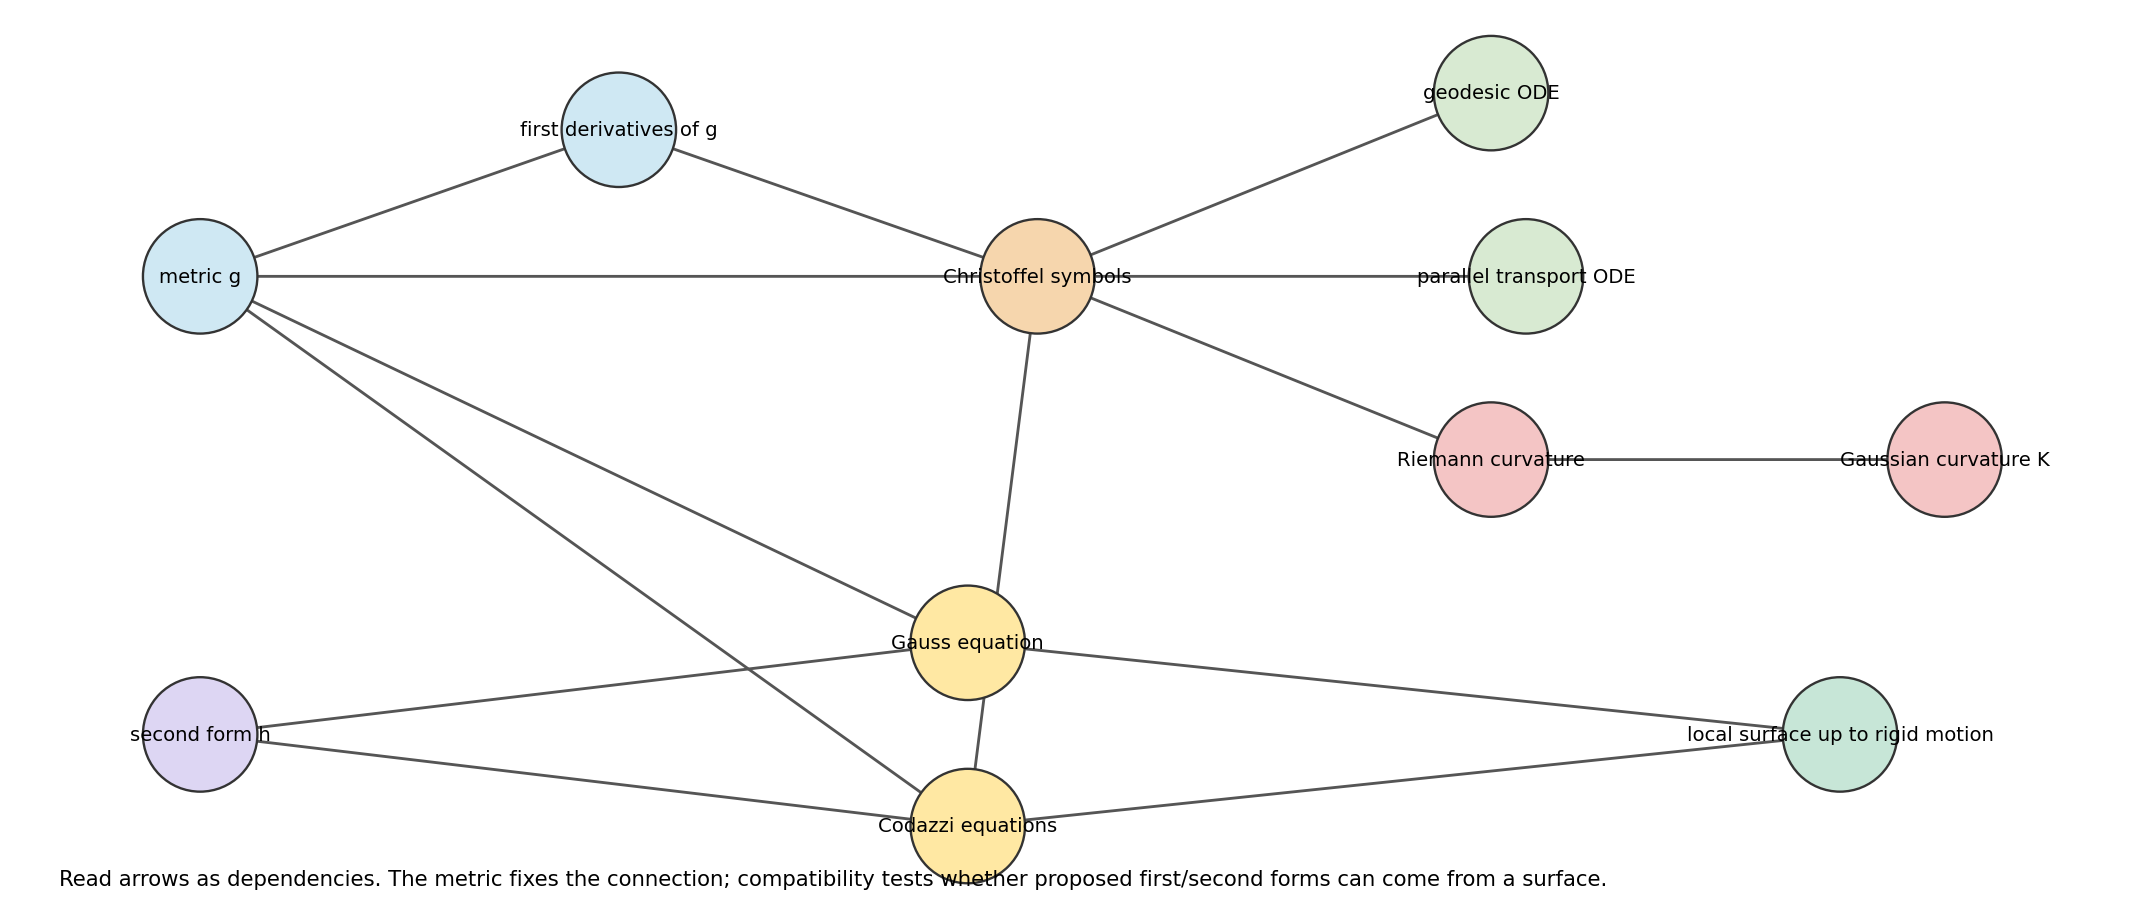

[{'symbol': 'Gamma^theta_phiphi', 'value': '-sin(2*theta)/2'},
 {'symbol': 'Gamma^phi_thetaphi', 'value': '1/tan(theta)'},
 {'symbol': 'Gamma^phi_phitheta', 'value': '1/tan(theta)'}]

In [6]:
from IPython.display import display

display_artifact(compatibility_fig_path, width=900)
display(christoffel_rows)


The graph is also a warning against a common misconception: the second fundamental form is extrinsic data, but it is not free once the first form is chosen. The appendix-level local theorem says that the compatibility equations are exactly the integrability conditions for building a surface from the prescribed data.


## Geodesics And Parallel Transport As ODEs

The geodesic equations are second-order ODEs whose coefficients are the Christoffel symbols. This is why existence and uniqueness theorems for ODEs enter the chapter. The same connection gives a first-order ODE for parallel transport along a chosen curve.

For the unit sphere in coordinates `(theta, phi)`, the metric is `dtheta^2 + sin(theta)^2 dphi^2`. The next cells integrate one geodesic from an arbitrary initial direction, then transport a vector around a latitude. The diagnostics check three intrinsic facts: speed stays constant, the geodesic is a great circle, and holonomy around the latitude matches the curvature area modulo `2*pi`.


In [7]:
from scipy.integrate import solve_ivp


def sphere_xyz(theta, phi):
    return np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)], dtype=float)


def sphere_partials(theta, phi):
    x_theta = np.array([np.cos(theta) * np.cos(phi), np.cos(theta) * np.sin(phi), -np.sin(theta)], dtype=float)
    x_phi = np.array([-np.sin(theta) * np.sin(phi), np.sin(theta) * np.cos(phi), 0.0], dtype=float)
    return x_theta, x_phi


def geodesic_rhs(t, y):
    theta, phi, theta_dot, phi_dot = y
    s = max(abs(np.sin(theta)), 1e-9)
    theta_ddot = np.sin(theta) * np.cos(theta) * phi_dot**2
    phi_ddot = -2.0 * (np.cos(theta) / s) * theta_dot * phi_dot
    return [theta_dot, phi_dot, theta_ddot, phi_ddot]


theta0 = 1.13
phi0 = 0.35
psi = 0.92
theta_dot0 = math.cos(psi)
phi_dot0 = math.sin(psi) / math.sin(theta0)
y0 = [theta0, phi0, theta_dot0, phi_dot0]
sol = solve_ivp(geodesic_rhs, (0.0, 5.2), y0, rtol=1e-10, atol=1e-12, dense_output=True, max_step=0.025)
ts = np.linspace(0.0, 5.2, 420)
ys = sol.sol(ts)
thetas, phis, theta_dots, phi_dots = ys
speed_sq = theta_dots**2 + (np.sin(thetas) ** 2) * phi_dots**2
speed_variation = float(np.max(np.abs(speed_sq - speed_sq[0])))
points = np.column_stack([sphere_xyz(a, b) for a, b in zip(thetas, phis)]).T
p0 = sphere_xyz(theta0, phi0)
xth0, xph0 = sphere_partials(theta0, phi0)
tangent0 = theta_dot0 * xth0 + phi_dot0 * xph0
plane_normal = np.cross(p0, tangent0)
plane_normal = plane_normal / np.linalg.norm(plane_normal)
great_circle_residual = float(np.max(np.abs(points @ plane_normal)))

# Parallel transport around a latitude theta=theta_loop.
theta_loop = 1.05
s_loop = math.sin(theta_loop)
c_loop = math.cos(theta_loop)


def transport_rhs(phi, w):
    a, b = w
    return [s_loop * c_loop * b, -(c_loop / s_loop) * a]

transport = solve_ivp(transport_rhs, (0.0, 2.0 * math.pi), [1.0, 0.0], rtol=1e-11, atol=1e-12, dense_output=True, max_step=0.01)
phis_loop = np.linspace(0.0, 2.0 * math.pi, 500)
ws = transport.sol(phis_loop)
orth_components = np.vstack([ws[0], s_loop * ws[1]])
transport_norms = np.sqrt(orth_components[0] ** 2 + orth_components[1] ** 2)
transport_norm_variation = float(np.max(np.abs(transport_norms - transport_norms[0])))
final_orth = np.array([ws[0, -1], s_loop * ws[1, -1]])
transport_angle = float(math.atan2(final_orth[1], final_orth[0]))
expected_angle = float(math.atan2(math.sin(-2 * math.pi * c_loop), math.cos(-2 * math.pi * c_loop)))
angle_residual = float(abs(math.atan2(math.sin(transport_angle - expected_angle), math.cos(transport_angle - expected_angle))))
cap_area = float(2.0 * math.pi * (1.0 - c_loop))
holonomy_area_mod_residual = float(abs(math.atan2(math.sin(transport_angle - cap_area), math.cos(transport_angle - cap_area))))

ode_checks = {
    "sphere_geodesic_speed_sq_variation": speed_variation,
    "sphere_geodesic_great_circle_plane_residual": great_circle_residual,
    "parallel_transport_norm_variation": transport_norm_variation,
    "parallel_transport_angle": transport_angle,
    "parallel_transport_expected_angle_mod": expected_angle,
    "parallel_transport_angle_residual": angle_residual,
    "latitude_cap_area": cap_area,
    "holonomy_area_mod_residual": holonomy_area_mod_residual,
}
assert speed_variation < 1e-8
assert great_circle_residual < 1e-8
assert transport_norm_variation < 1e-8
assert angle_residual < 1e-8
assert holonomy_area_mod_residual < 1e-8
ode_checks


{'sphere_geodesic_speed_sq_variation': 2.1335688771273453e-10,
 'sphere_geodesic_great_circle_plane_residual': 1.630129364826871e-11,
 'parallel_transport_norm_variation': 3.3306690738754696e-15,
 'parallel_transport_angle': -3.1263310973912493,
 'parallel_transport_expected_angle_mod': -3.1263310973912493,
 'parallel_transport_angle_residual': 0.0,
 'latitude_cap_area': 3.156854209788337,
 'holonomy_area_mod_residual': 2.4492935982947064e-16}

In [8]:
fig = plt.figure(figsize=(13.5, 8.2), constrained_layout=True)
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
u = np.linspace(0.0, math.pi, 44)
v = np.linspace(0.0, 2.0 * math.pi, 88)
U, V = np.meshgrid(u, v, indexing="ij")
X = np.sin(U) * np.cos(V)
Y = np.sin(U) * np.sin(V)
Z = np.cos(U)
ax3d.plot_surface(X, Y, Z, color="#d9e8f5", alpha=0.38, linewidth=0, shade=False)
ax3d.plot(points[:, 0], points[:, 1], points[:, 2], color="#b23a48", lw=3)
loop = np.column_stack([sphere_xyz(theta_loop, p) for p in phis_loop]).T
ax3d.plot(loop[:, 0], loop[:, 1], loop[:, 2], color="#2a9d8f", lw=2.2)
ax3d.scatter([p0[0]], [p0[1]], [p0[2]], color="black", s=24)
ax3d.set_title("Geodesic stays in a great-circle plane")
ax3d.set_axis_off()
ax3d.set_box_aspect((1, 1, 1))
ax3d.view_init(elev=22, azim=-40)

ax_speed = fig.add_subplot(2, 2, 2)
ax_speed.plot(ts, speed_sq, color="#264653", lw=2)
ax_speed.axhline(speed_sq[0], color="#999999", lw=1, ls="--")
ax_speed.set_title("Intrinsic speed along geodesic")
ax_speed.set_xlabel("time")
ax_speed.set_ylabel("g(gamma', gamma')")
ax_speed.grid(alpha=0.25)

ax_phase = fig.add_subplot(2, 2, 3)
ax_phase.plot(thetas, phis, color="#b23a48", lw=2)
ax_phase.set_title("Coordinate trace solves the geodesic ODE")
ax_phase.set_xlabel("theta")
ax_phase.set_ylabel("phi")
ax_phase.grid(alpha=0.25)

ax_transport = fig.add_subplot(2, 2, 4)
ax_transport.plot(orth_components[0], orth_components[1], color="#2a9d8f", lw=2)
ax_transport.scatter([1, final_orth[0]], [0, final_orth[1]], color=["black", "#b23a48"], zorder=3)
unit_circle = np.linspace(0.0, 2.0 * math.pi, 240)
ax_transport.plot(np.cos(unit_circle), np.sin(unit_circle), color="#cccccc", lw=1)
ax_transport.set_aspect("equal")
ax_transport.set_title("Parallel transport in an orthonormal frame")
ax_transport.set_xlabel("e_theta component")
ax_transport.set_ylabel("e_phi component")
ax_transport.grid(alpha=0.25)

ode_fig_path = FIG_DIR / "sphere-geodesic-ode-and-transport.png"
fig.savefig(ode_fig_path, dpi=170, bbox_inches="tight")
plt.close(fig)
ode_fig_path.relative_to(BOOK_ROOT)


WindowsPath('artifacts/chapter-04/figures/sphere-geodesic-ode-and-transport.png')

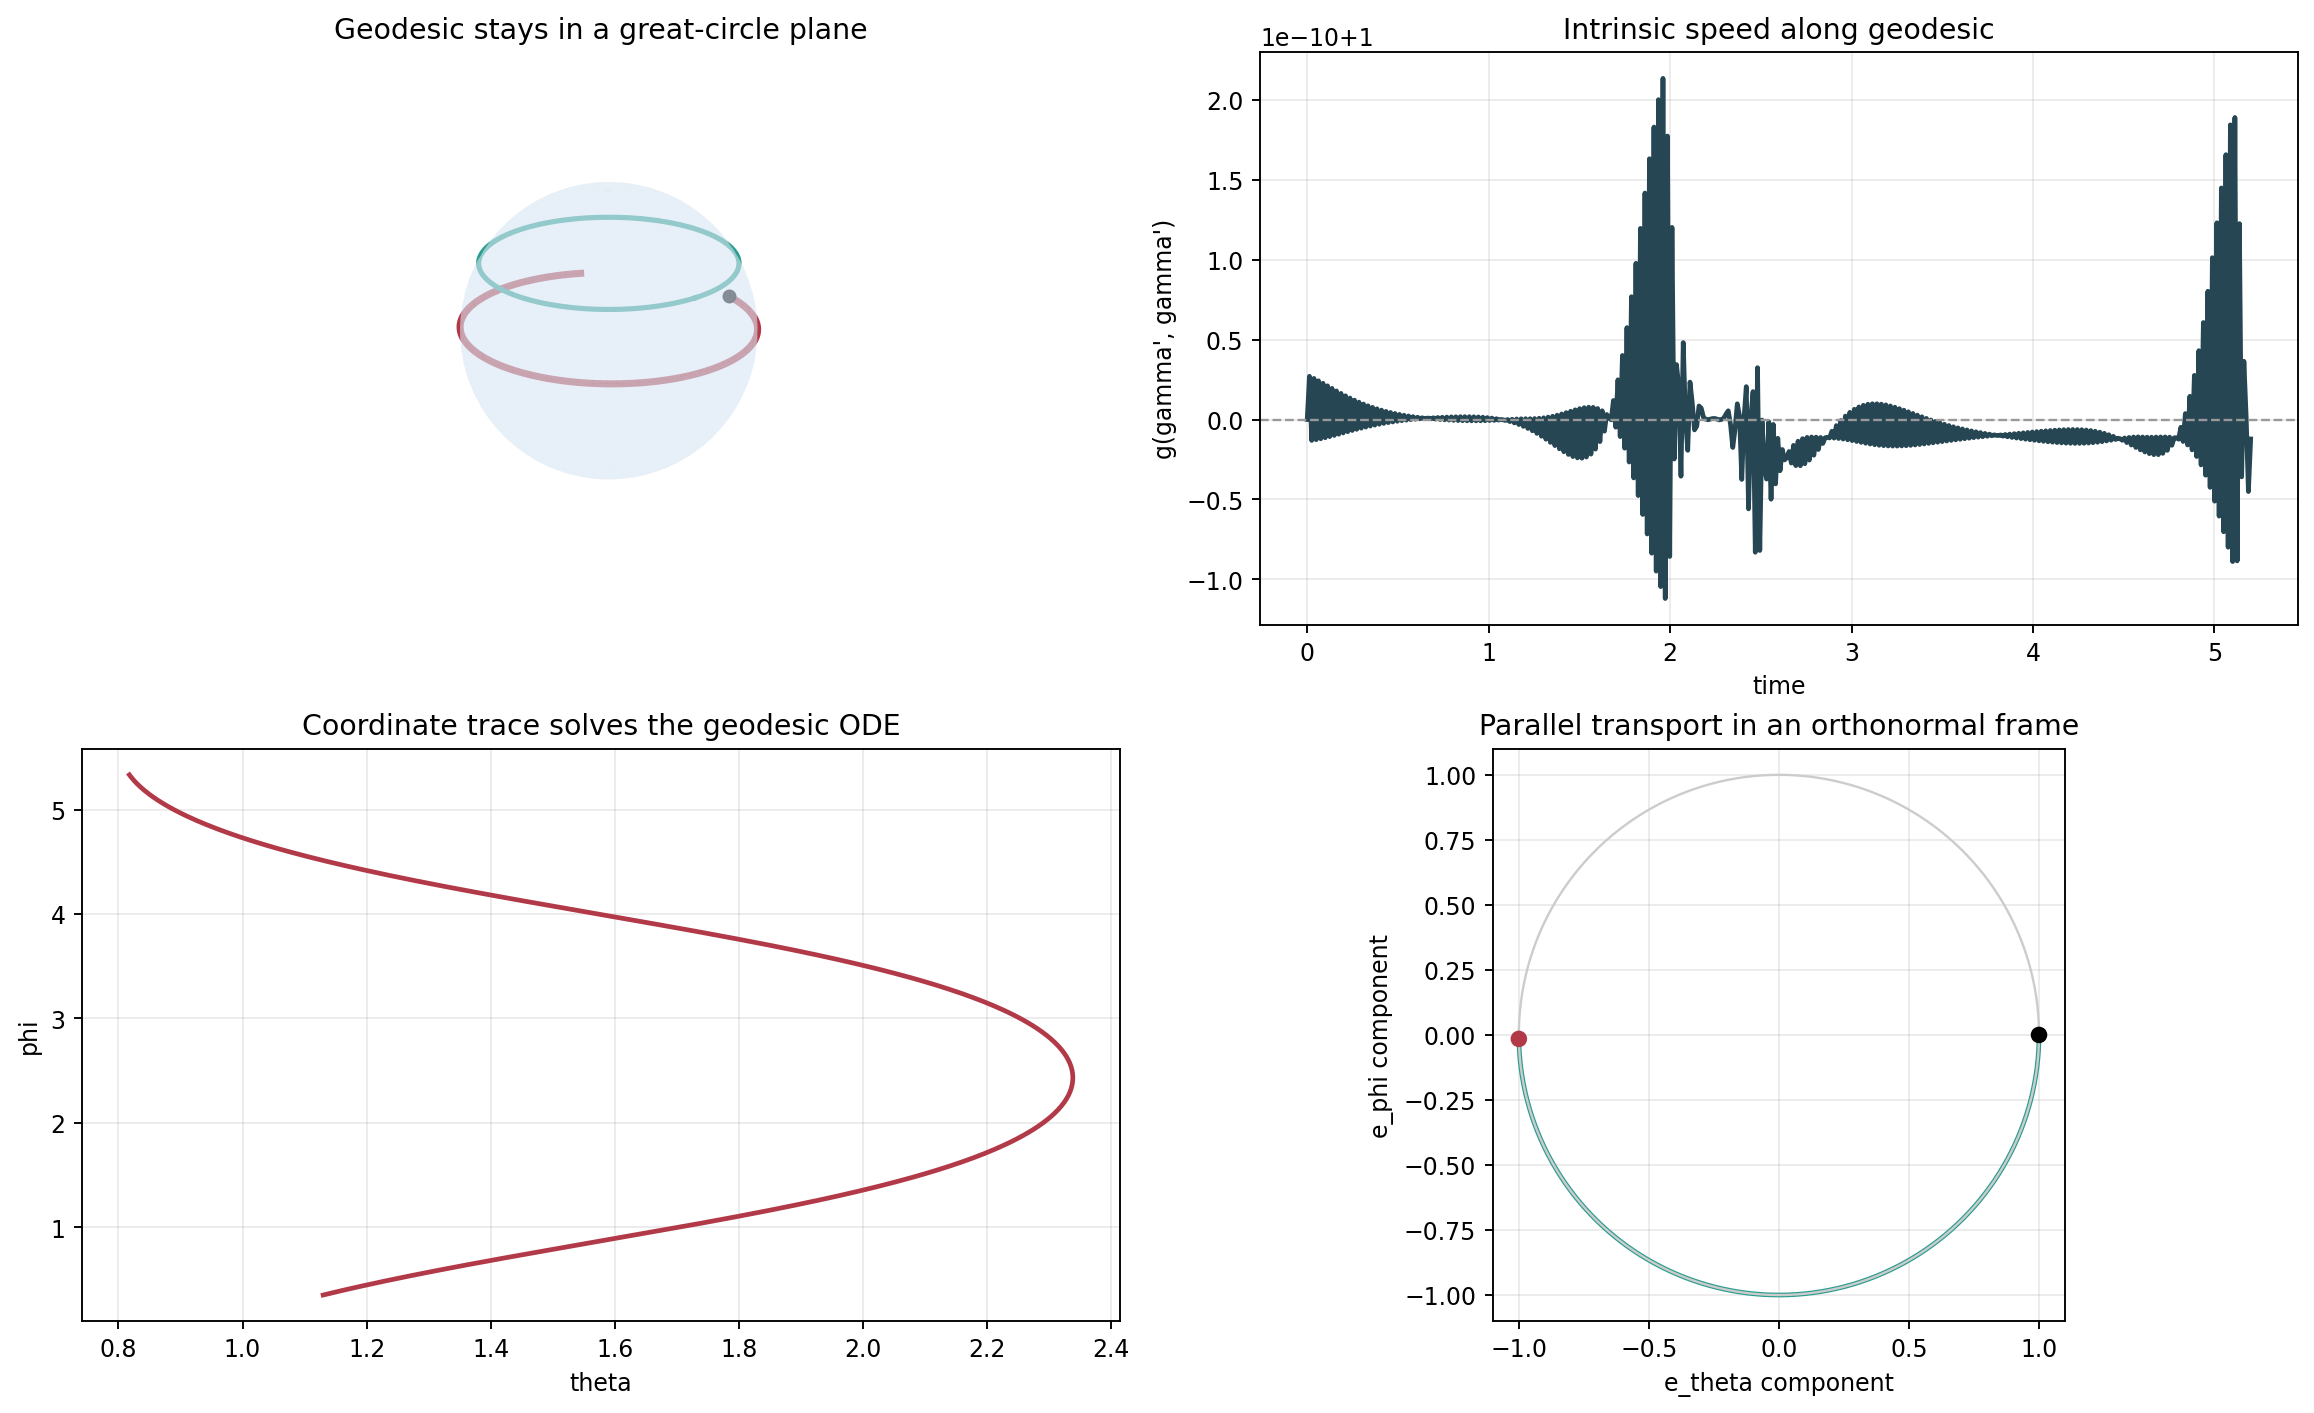

In [9]:
display_artifact(ode_fig_path, width=900)


In [10]:
import plotly.graph_objects as go

fan_traces = []
fan_angles = np.linspace(-0.8, 0.8, 7)
fan_start = [1.12, -0.85]
for fan_angle in fan_angles:
    yd0 = [fan_start[0], fan_start[1], math.cos(fan_angle), math.sin(fan_angle) / math.sin(fan_start[0])]
    fan_sol = solve_ivp(geodesic_rhs, (0.0, 1.65), yd0, rtol=1e-9, atol=1e-11, dense_output=True, max_step=0.025)
    fan_ts = np.linspace(0.0, 1.65, 140)
    fan_y = fan_sol.sol(fan_ts)
    fan_pts = np.column_stack([sphere_xyz(a, b) for a, b in zip(fan_y[0], fan_y[1])]).T
    fan_traces.append(go.Scatter3d(x=fan_pts[:, 0], y=fan_pts[:, 1], z=fan_pts[:, 2], mode="lines", line=dict(width=5, color="#b23a48"), showlegend=False, hoverinfo="skip"))

surface = go.Surface(x=X, y=Y, z=Z, showscale=False, opacity=0.42, colorscale=[[0, "#d8e9f3"], [1, "#d8e9f3"]], hoverinfo="skip")
geodesic_trace = go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode="lines", line=dict(width=7, color="#264653"), name="geodesic ODE")
loop_trace = go.Scatter3d(x=loop[:, 0], y=loop[:, 1], z=loop[:, 2], mode="lines", line=dict(width=6, color="#2a9d8f"), name="latitude transport loop")
start_trace = go.Scatter3d(x=[p0[0]], y=[p0[1]], z=[p0[2]], mode="markers", marker=dict(size=5, color="black"), name="initial point")

vector_traces = []
for idx in np.linspace(0, len(phis_loop) - 1, 8, dtype=int):
    phi = phis_loop[idx]
    a = ws[0, idx]
    b = ws[1, idx]
    xth, xph = sphere_partials(theta_loop, phi)
    base = sphere_xyz(theta_loop, phi)
    vec = a * xth + b * xph
    tip = base + 0.18 * vec / np.linalg.norm(vec)
    vector_traces.append(go.Scatter3d(x=[base[0], tip[0]], y=[base[1], tip[1]], z=[base[2], tip[2]], mode="lines", line=dict(width=5, color="#f4a261"), showlegend=False, hoverinfo="skip"))

fig_plotly = go.Figure(data=[surface, geodesic_trace, loop_trace, start_trace, *fan_traces, *vector_traces])
fig_plotly.update_layout(title="Chapter 4: geodesic flow and parallel transport on the unit sphere", scene=dict(aspectmode="data", xaxis_visible=False, yaxis_visible=False, zaxis_visible=False), margin=dict(l=0, r=0, t=45, b=0), legend=dict(x=0.02, y=0.98))
interactive_path = HTML_DIR / "sphere-geodesic-flow-and-holonomy.html"
fig_plotly.write_html(interactive_path, include_plotlyjs=True, full_html=True)
interactive_path.relative_to(BOOK_ROOT)


WindowsPath('artifacts/chapter-04/interactive/sphere-geodesic-flow-and-holonomy.html')

In [11]:
from IPython.display import IFrame, display

interactive_src = "../" + str(interactive_path.relative_to(BOOK_ROOT)).replace("\\", "/")
display(IFrame(src=interactive_src, width="100%", height=560))


The latitude loop is not a geodesic, but it is a clean transport laboratory. A tangent vector can keep its intrinsic length and still return rotated. The rotation is not a coordinate error: modulo `2*pi`, it records the curvature area enclosed by the loop.


## Gauss-Bonnet And Exponential Coordinates

For a geodesic triangle, the boundary geodesic curvature terms vanish along the sides, so Gauss-Bonnet reduces to an angle ledger: interior angle excess equals integrated Gaussian curvature. On the unit sphere, curvature is `1`, so the excess equals area.

Geodesic polar coordinates give a local microscope for the same curvature. In constant curvature `K`, the metric has the form `d rho^2 + S_K(rho)^2 d theta^2`, where `S_K` solves `S_K'' + K S_K = 0`, `S_K(0)=0`, `S_K'(0)=1`. Positive curvature makes nearby radial geodesics converge; negative curvature makes them spread faster than in the plane.


In [12]:
import trimesh

alpha = math.pi / 3.0
spherical_triangle_angles = np.array([alpha, math.pi / 2.0, math.pi / 2.0])
angle_excess = float(np.sum(spherical_triangle_angles) - math.pi)
spherical_triangle_area = alpha
triangle_residual = float(abs(angle_excess - spherical_triangle_area))

rhos = np.linspace(1e-4, 2.6, 400)
S_pos = np.sin(rhos)
S_zero = rhos
S_neg = np.sinh(rhos)
polar_residual = float(max(np.max(np.abs(-np.sin(rhos) + S_pos)), np.max(np.abs(0.0 * S_zero)), np.max(np.abs(np.sinh(rhos) - S_neg))))
small_r = 0.35
circle_lengths = {"K=1": float(2 * math.pi * math.sin(small_r)), "K=0": float(2 * math.pi * small_r), "K=-1": float(2 * math.pi * math.sinh(small_r))}

sphere_mesh = trimesh.creation.icosphere(subdivisions=3, radius=1.0)
nu, nv = 36, 18
verts = []
faces = []
major, minor = 2.0, 0.55
for i in range(nu):
    uu = 2 * math.pi * i / nu
    for j in range(nv):
        vv = 2 * math.pi * j / nv
        verts.append([(major + minor * math.cos(vv)) * math.cos(uu), (major + minor * math.cos(vv)) * math.sin(uu), minor * math.sin(vv)])
for i in range(nu):
    for j in range(nv):
        a0 = i * nv + j
        a1 = ((i + 1) % nu) * nv + j
        a2 = ((i + 1) % nu) * nv + ((j + 1) % nv)
        a3 = i * nv + ((j + 1) % nv)
        faces.append([a0, a1, a2])
        faces.append([a0, a2, a3])
torus_mesh = trimesh.Trimesh(vertices=np.array(verts), faces=np.array(faces), process=False)
mesh_ledgers = [
    {"surface": "sphere mesh", "euler_number": int(sphere_mesh.euler_number), "total_curvature_target": float(2 * math.pi * sphere_mesh.euler_number)},
    {"surface": "torus mesh", "euler_number": int(torus_mesh.euler_number), "total_curvature_target": float(2 * math.pi * torus_mesh.euler_number)},
]

bonnet_checks = {
    "spherical_triangle_alpha": alpha,
    "spherical_triangle_angle_excess": angle_excess,
    "spherical_triangle_area": spherical_triangle_area,
    "spherical_triangle_excess_area_residual": triangle_residual,
    "polar_spreading_analytic_ode_residual": polar_residual,
    "geodesic_circle_lengths_r_0_35": circle_lengths,
    "mesh_global_gauss_bonnet_ledgers": mesh_ledgers,
}
assert triangle_residual < 1e-12
assert polar_residual < 1e-12
assert sphere_mesh.euler_number == 2
assert torus_mesh.euler_number == 0
bonnet_checks


{'spherical_triangle_alpha': 1.0471975511965976,
 'spherical_triangle_angle_excess': 1.0471975511965974,
 'spherical_triangle_area': 1.0471975511965976,
 'spherical_triangle_excess_area_residual': 2.220446049250313e-16,
 'polar_spreading_analytic_ode_residual': 0.0,
 'geodesic_circle_lengths_r_0_35': {'K=1': 2.1544904656681867,
  'K=0': 2.199114857512855,
  'K=-1': 2.2442892598757185},
 'mesh_global_gauss_bonnet_ledgers': [{'surface': 'sphere mesh',
   'euler_number': 2,
   'total_curvature_target': 12.566370614359172},
  {'surface': 'torus mesh', 'euler_number': 0, 'total_curvature_target': 0.0}]}

In [13]:
fig = plt.figure(figsize=(14.0, 8.4), constrained_layout=True)
ax_tri = fig.add_subplot(2, 2, 1, projection="3d")
ax_bar = fig.add_subplot(2, 2, 2)
ax_spread = fig.add_subplot(2, 2, 3)
ax_circle = fig.add_subplot(2, 2, 4)

ax_tri.plot_surface(X, Y, Z, color="#d9e8f5", alpha=0.35, linewidth=0, shade=False)
edge1 = np.column_stack([sphere_xyz(t, 0.0) for t in np.linspace(0, math.pi / 2, 100)]).T
edge2 = np.column_stack([sphere_xyz(t, alpha) for t in np.linspace(0, math.pi / 2, 100)]).T
edge3 = np.column_stack([sphere_xyz(math.pi / 2, p) for p in np.linspace(0, alpha, 100)]).T
for edge in [edge1, edge2, edge3]:
    ax_tri.plot(edge[:, 0], edge[:, 1], edge[:, 2], color="#b23a48", lw=3)
verts_tri = np.array([sphere_xyz(0, 0), sphere_xyz(math.pi / 2, 0), sphere_xyz(math.pi / 2, alpha)])
ax_tri.scatter(verts_tri[:, 0], verts_tri[:, 1], verts_tri[:, 2], color="black", s=18)
ax_tri.set_title(f"Spherical geodesic triangle: excess = area = {angle_excess:.3f}")
ax_tri.set_axis_off()
ax_tri.set_box_aspect((1, 1, 1))
ax_tri.view_init(elev=24, azim=-52)

names = [row["surface"] for row in mesh_ledgers]
values = [row["total_curvature_target"] for row in mesh_ledgers]
ax_bar.bar(names, values, color=["#264653", "#2a9d8f"])
ax_bar.axhline(0, color="#666666", lw=1)
ax_bar.set_ylabel("2*pi*chi")
ax_bar.set_title("Global Gauss-Bonnet target from mesh topology")
ax_bar.tick_params(axis="x", rotation=10)

ax_spread.plot(rhos, S_pos, label="K=1: sin rho", color="#264653", lw=2)
ax_spread.plot(rhos, S_zero, label="K=0: rho", color="#555555", lw=2)
ax_spread.plot(rhos, S_neg, label="K=-1: sinh rho", color="#b23a48", lw=2)
ax_spread.set_title("Exponential polar spreading S_K(rho)")
ax_spread.set_xlabel("rho")
ax_spread.set_ylabel("distance scale around geodesic circle")
ax_spread.grid(alpha=0.25)
ax_spread.legend(fontsize=9)

labels = list(circle_lengths)
length_values = [circle_lengths[k] for k in labels]
ax_circle.bar(labels, length_values, color=["#264653", "#555555", "#b23a48"])
ax_circle.set_title(f"Geodesic circle length at rho={small_r}")
ax_circle.set_ylabel("2*pi*S_K(rho)")
ax_circle.grid(axis="y", alpha=0.25)

bonnet_fig_path = FIG_DIR / "gauss-bonnet-exponential-coordinates.png"
fig.savefig(bonnet_fig_path, dpi=170, bbox_inches="tight")
plt.close(fig)
bonnet_fig_path.relative_to(BOOK_ROOT)


WindowsPath('artifacts/chapter-04/figures/gauss-bonnet-exponential-coordinates.png')

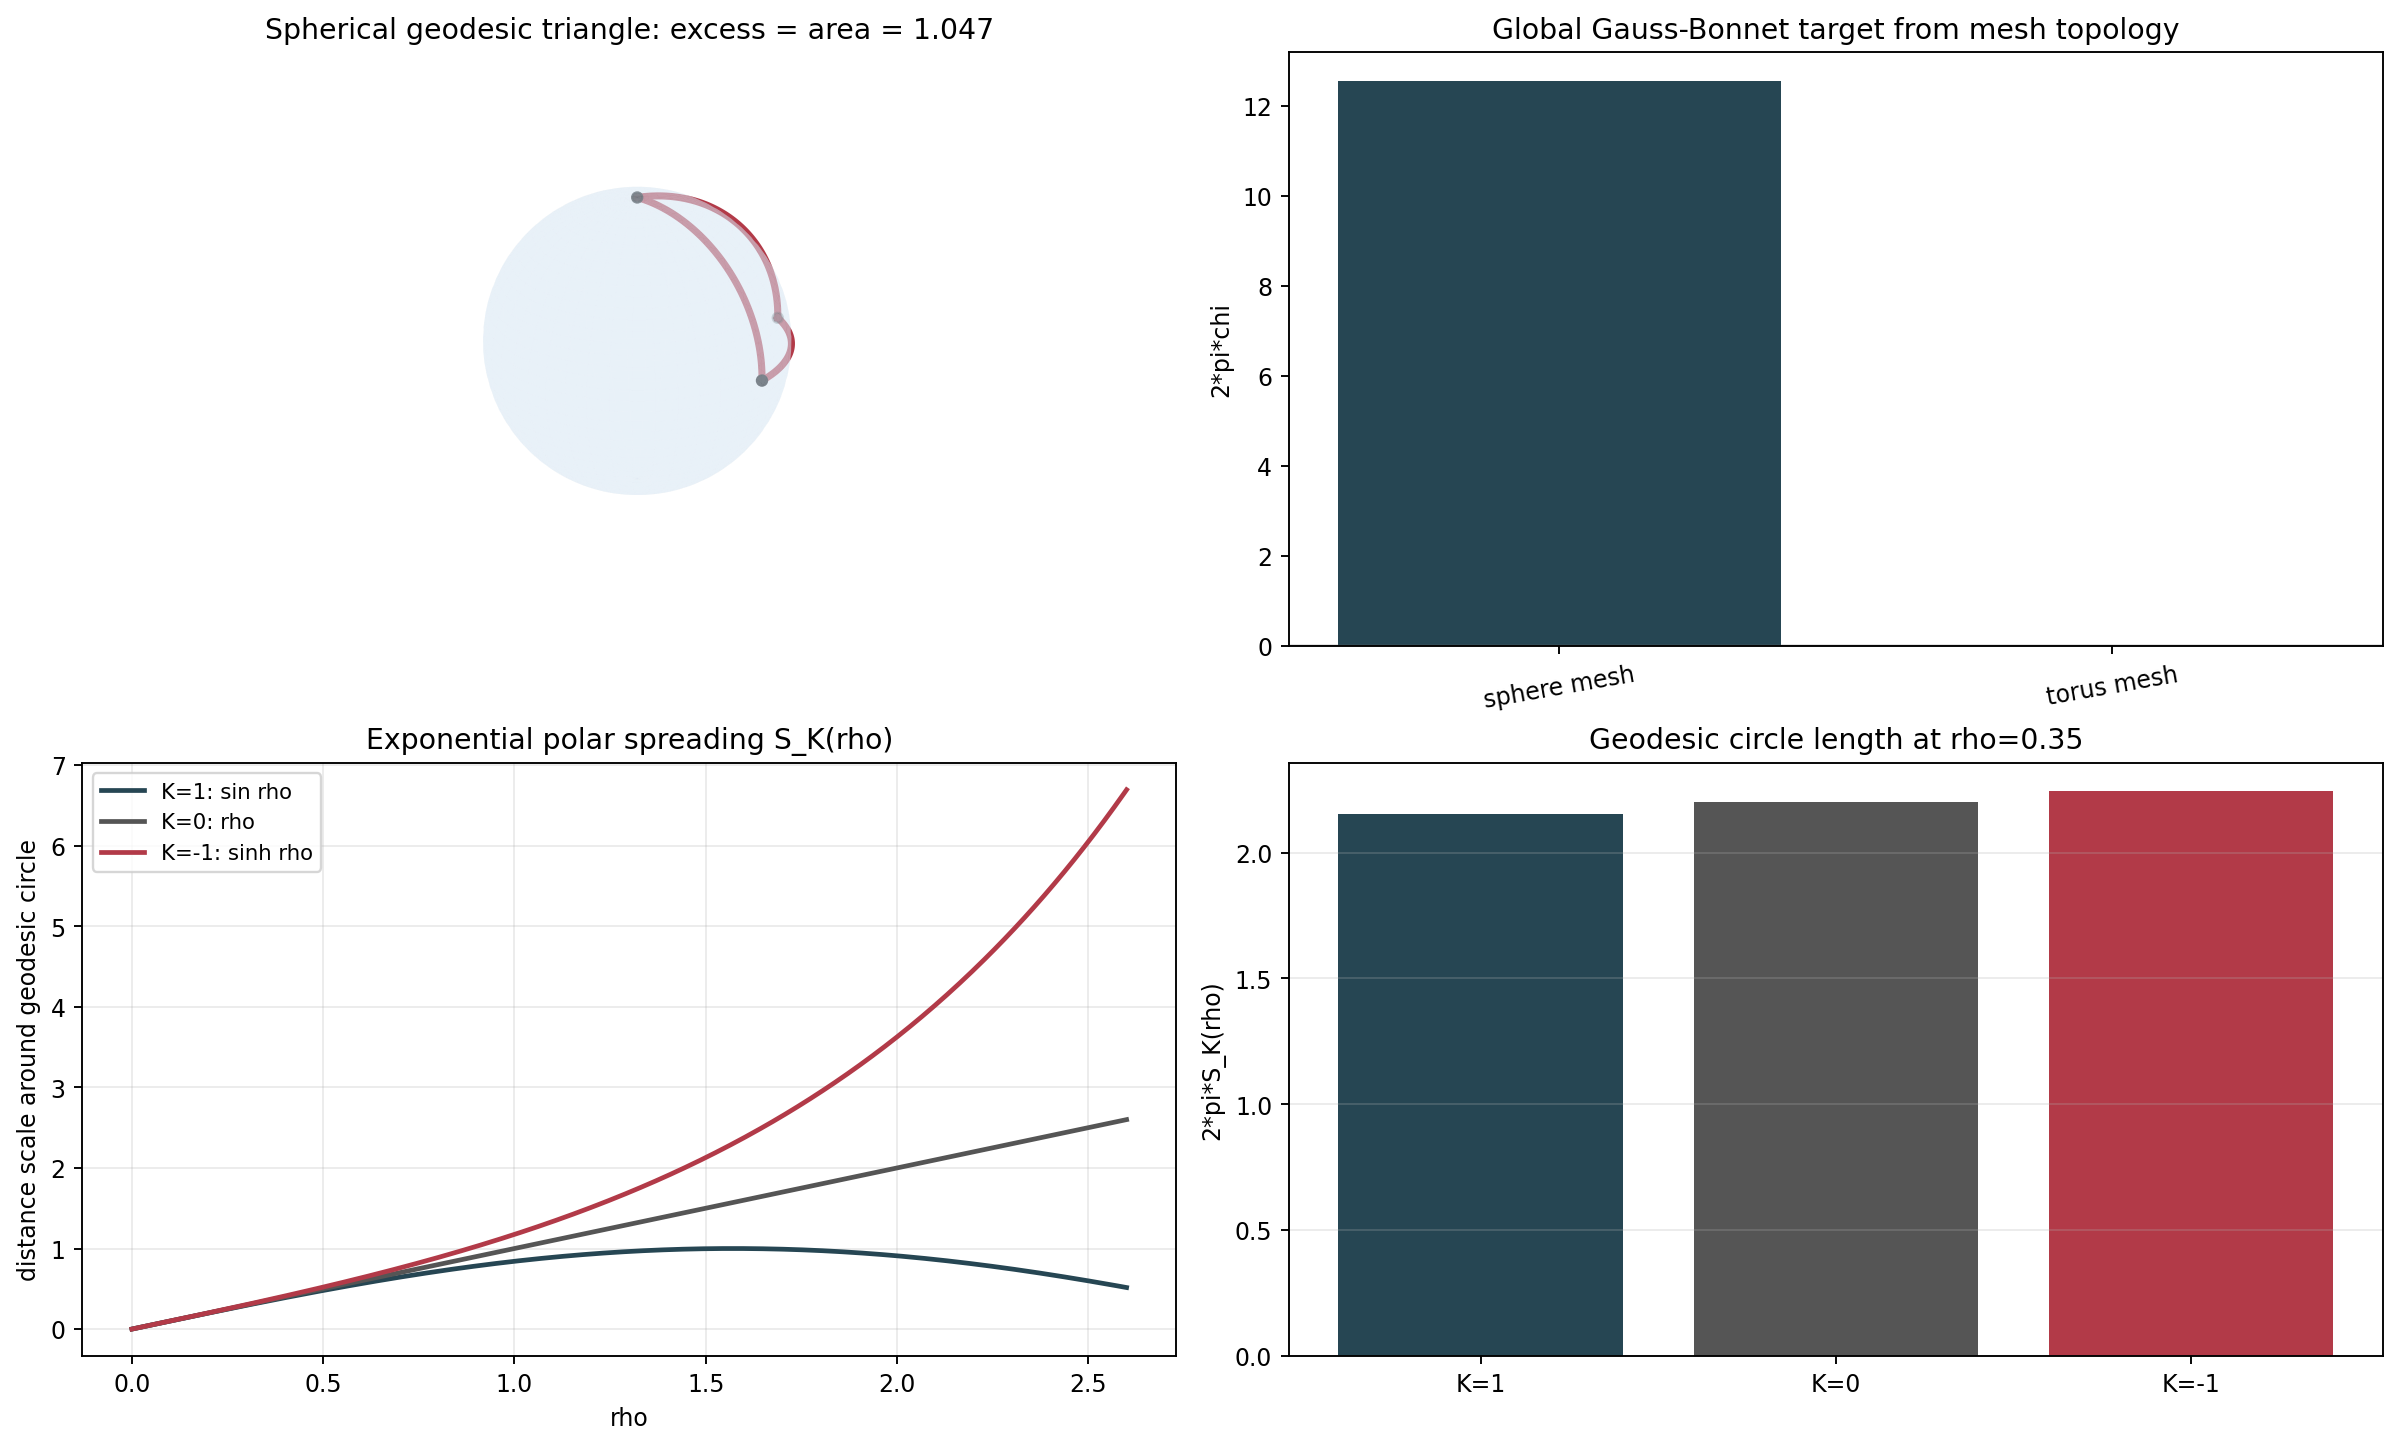

In [14]:
display_artifact(bonnet_fig_path, width=900)


The topology panel does not numerically integrate curvature over a mesh. It does something narrower and still useful: it checks the Euler characteristic side of the global theorem on actual triangulated surfaces. For a compact oriented surface, the target total curvature is `2*pi*chi`; for a torus this target is zero even though local curvature need not vanish everywhere.


## Applied Lab: Clairaut's Constant From The Same Geodesic

Surfaces of revolution have a conserved quantity along geodesics. On the unit sphere, the radius of a parallel is `sin(theta)`. If `alpha` is the angle with a meridian in the orthonormal frame, then `sin(theta) sin(alpha)` stays constant. In coordinate velocities this is `sin(theta)^2 phi'`.

The lab below reuses the geodesic ODE and tracks that invariant. Change `psi` in the earlier geodesic initial condition, rerun from there, and inspect how the oscillation in latitude changes while the invariant remains flat.


In [15]:
clairaut_values = (np.sin(thetas) ** 2) * phi_dots
clairaut_variation = float(np.max(np.abs(clairaut_values - clairaut_values[0])))
lab_rows = []
for idx in np.linspace(0, len(ts) - 1, 12, dtype=int):
    theta_val = float(thetas[idx])
    phi_dot_val = float(phi_dots[idx])
    speed_val = float(math.sqrt(speed_sq[idx]))
    sin_alpha = float((math.sin(theta_val) * phi_dot_val) / speed_val)
    lab_rows.append({
        "t": float(ts[idx]),
        "theta": theta_val,
        "parallel_radius_sin_theta": float(math.sin(theta_val)),
        "sin_angle_with_meridian": sin_alpha,
        "clairaut_sin2theta_phidot": float(clairaut_values[idx]),
    })

lab_table_path = TABLE_DIR / "applied-lab-clairaut.csv"
with lab_table_path.open("w", newline="", encoding="utf-8") as fh:
    writer = csv.DictWriter(fh, fieldnames=list(lab_rows[0].keys()))
    writer.writeheader()
    writer.writerows(lab_rows)

fig, ax = plt.subplots(figsize=(10.5, 4.2), constrained_layout=True)
ax.plot(ts, clairaut_values, color="#264653", lw=2, label="sin(theta)^2 phi'")
ax.axhline(clairaut_values[0], color="#999999", lw=1, ls="--", label="initial value")
ax.set_xlabel("time")
ax.set_ylabel("Clairaut quantity")
ax.set_title("Applied lab diagnostic: conserved quantity along a sphere geodesic")
ax.grid(alpha=0.25)
ax.legend()
clairaut_fig_path = FIG_DIR / "applied-lab-clairaut-invariant.png"
fig.savefig(clairaut_fig_path, dpi=170, bbox_inches="tight")
plt.close(fig)

lab_checks = {"clairaut_variation": clairaut_variation, "clairaut_initial_value": float(clairaut_values[0]), "lab_rows": len(lab_rows)}
assert clairaut_variation < 1e-8
lab_checks


{'clairaut_variation': 7.434053372890048e-11,
 'clairaut_initial_value': 0.7195518030504305,
 'lab_rows': 12}

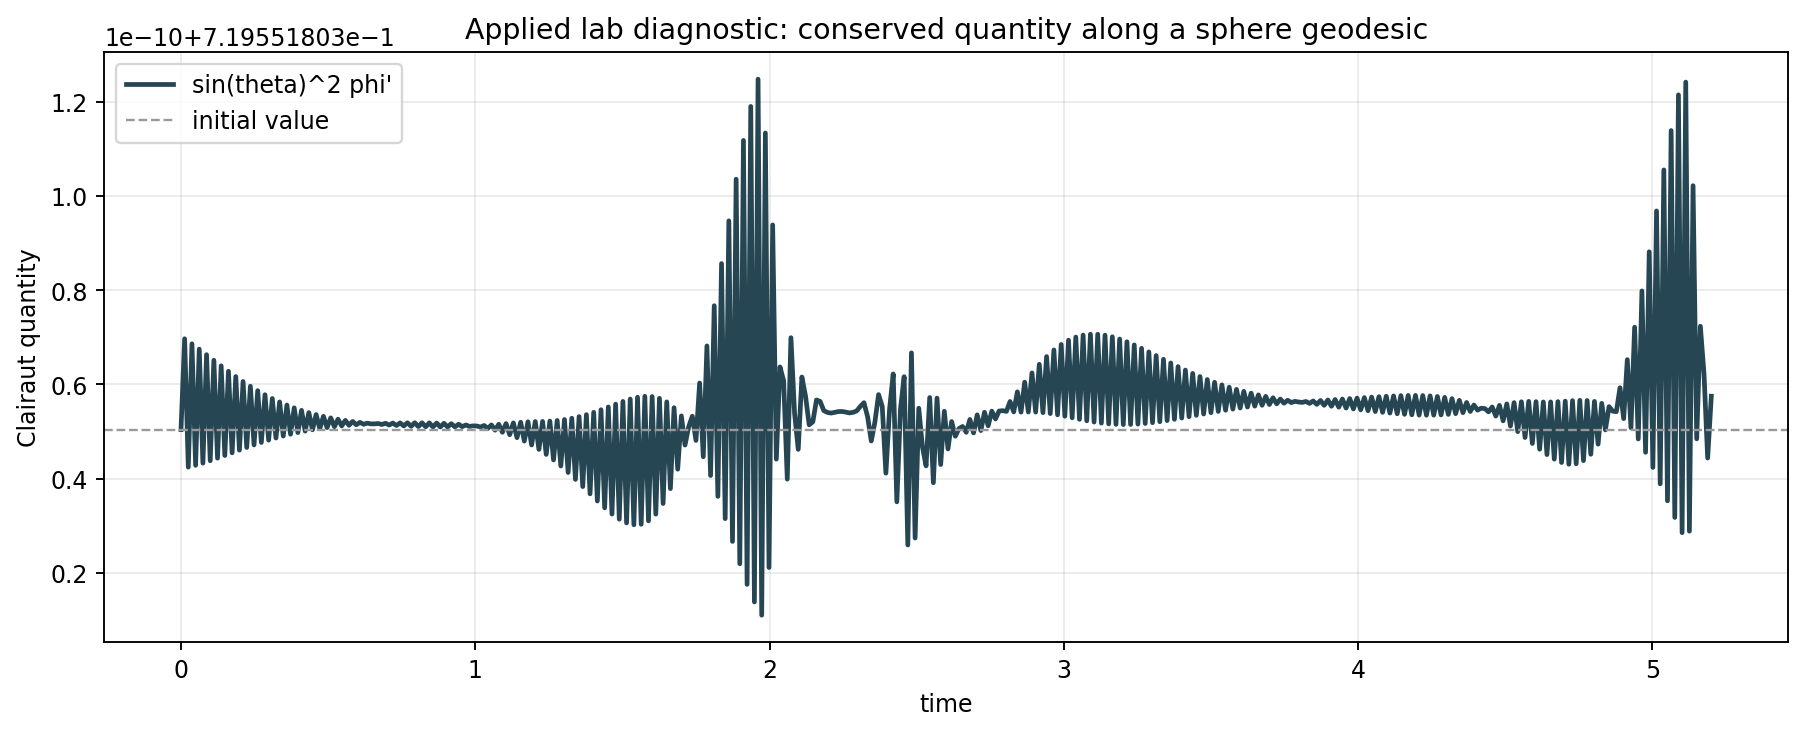

[{'t': 0.0,
  'theta': 1.13,
  'parallel_radius_sin_theta': 0.9044121893788258,
  'sin_angle_with_meridian': 0.795601620036366,
  'clairaut_sin2theta_phidot': 0.7195518030504305},
 {'t': 0.4715990453460621,
  'theta': 1.4392526559133598,
  'parallel_radius_sin_theta': 0.9913605999370529,
  'sin_angle_with_meridian': 0.7258224737768232,
  'clairaut_sin2theta_phidot': 0.719551803050639},
 {'t': 0.9431980906921242,
  'theta': 1.7649800129821611,
  'parallel_radius_sin_theta': 0.9812055169614592,
  'sin_angle_with_meridian': 0.7333344448360392,
  'clairaut_sin2theta_phidot': 0.7195518030515653},
 {'t': 1.4147971360381864,
  'theta': 2.065724876333078,
  'parallel_radius_sin_theta': 0.8800026488208429,
  'sin_angle_with_meridian': 0.8176700422512403,
  'clairaut_sin2theta_phidot': 0.7195518030352787},
 {'t': 1.8863961813842485,
  'theta': 2.282704349789897,
  'parallel_radius_sin_theta': 0.757116782493707,
  'sin_angle_with_meridian': 0.9503841675189149,
  'clairaut_sin2theta_phidot': 0.719

In [16]:
from IPython.display import display

display_artifact(clairaut_fig_path, width=850)
display(lab_rows[:5])


The lab is intentionally small but not decorative. It connects the chapter's abstract connection machinery to a concrete prediction: a geodesic on a rotationally symmetric surface trades radius against direction in a constrained way.


## Final Sanity Checks

The final cell writes a reproducible ledger under `artifacts/chapter-04/checks/`. It checks symbolic identities, ODE residuals, artifact existence and size, CSV creation, and simple image nonblankness. These tests do not replace proofs, but they catch common computational notebook failures: stale paths, blank visuals, broken formulas, and ODE examples that no longer satisfy the geometry they claim to show.


In [17]:
from PIL import Image

artifacts = {
    "metric_tests": metric_fig_path,
    "compatibility_graph": compatibility_fig_path,
    "geodesic_transport": ode_fig_path,
    "interactive_geodesic_holonomy": interactive_path,
    "gauss_bonnet_exponential": bonnet_fig_path,
    "clairaut_lab": clairaut_fig_path,
    "christoffel_table": christoffel_table_path,
    "clairaut_table": lab_table_path,
}
all_checks = {
    "metric": metric_checks,
    "symbolic": symbolic_checks,
    "compatibility": compatibility_checks,
    "ode": ode_checks,
    "gauss_bonnet_exponential": bonnet_checks,
    "applied_lab": lab_checks,
}

image_stats = {}
for name, path in artifacts.items():
    min_bytes = 5000 if path.suffix.lower() == ".html" else (32 if path.suffix.lower() == ".csv" else 512)
    assert_artifact(path, min_bytes=min_bytes)
    if path.suffix.lower() == ".png":
        with Image.open(path) as img:
            arr = np.asarray(img.convert("L"))
            image_stats[name] = {"size": list(img.size), "pixel_std": float(np.std(arr))}
        assert image_stats[name]["pixel_std"] > 1.0

assert metric_checks["cylinder_plane_isometry_pullback_inf_norm"] < 1e-12
assert metric_checks["analytic_conformal_pullback_inf_norm"] < 1e-12
assert symbolic_checks["sphere_curvature_residual_vs_1_over_R2"] == "0"
assert ode_checks["sphere_geodesic_speed_sq_variation"] < 1e-8
assert ode_checks["parallel_transport_angle_residual"] < 1e-8
assert bonnet_checks["spherical_triangle_excess_area_residual"] < 1e-12
assert lab_checks["clairaut_variation"] < 1e-8

checks_path = CHECK_DIR / "intrinsic-geometry-checks.json"
checks_path.write_text(json.dumps(all_checks, indent=2, sort_keys=True), encoding="utf-8")

final_sanity = {
    "unit": UNIT,
    "source_span": "printed pp. 220-320 / PDF pp. 236-336",
    "artifact_count": len(artifacts),
    "artifacts": {name: str(path.relative_to(BOOK_ROOT)).replace("\\", "/") for name, path in artifacts.items()},
    "artifact_sizes": {name: path.stat().st_size for name, path in artifacts.items()},
    "image_stats": image_stats,
    "check_file": str(checks_path.relative_to(BOOK_ROOT)).replace("\\", "/"),
    "max_residuals": {
        "isometry_pullback": metric_checks["cylinder_plane_isometry_pullback_inf_norm"],
        "conformal_pullback": metric_checks["analytic_conformal_pullback_inf_norm"],
        "geodesic_speed": ode_checks["sphere_geodesic_speed_sq_variation"],
        "great_circle_plane": ode_checks["sphere_geodesic_great_circle_plane_residual"],
        "transport_angle": ode_checks["parallel_transport_angle_residual"],
        "gauss_bonnet_triangle": bonnet_checks["spherical_triangle_excess_area_residual"],
        "clairaut": lab_checks["clairaut_variation"],
    },
}

final_sanity_path = CHECK_DIR / "final-sanity.json"
final_sanity_path.write_text(json.dumps(final_sanity, indent=2, sort_keys=True), encoding="utf-8")
assert_artifact(final_sanity_path, min_bytes=512)
final_sanity


{'unit': 'chapter-04',
 'source_span': 'printed pp. 220-320 / PDF pp. 236-336',
 'artifact_count': 8,
 'artifacts': {'metric_tests': 'artifacts/chapter-04/figures/isometry-conformal-metric-tests.png',
  'compatibility_graph': 'artifacts/chapter-04/figures/christoffel-compatibility-proof-graph.png',
  'geodesic_transport': 'artifacts/chapter-04/figures/sphere-geodesic-ode-and-transport.png',
  'interactive_geodesic_holonomy': 'artifacts/chapter-04/interactive/sphere-geodesic-flow-and-holonomy.html',
  'gauss_bonnet_exponential': 'artifacts/chapter-04/figures/gauss-bonnet-exponential-coordinates.png',
  'clairaut_lab': 'artifacts/chapter-04/figures/applied-lab-clairaut-invariant.png',
  'christoffel_table': 'artifacts/chapter-04/tables/christoffel-symbols-sphere.csv',
  'clairaut_table': 'artifacts/chapter-04/tables/applied-lab-clairaut.csv'},
 'artifact_sizes': {'metric_tests': 215580,
  'compatibility_graph': 161541,
  'geodesic_transport': 222890,
  'interactive_geodesic_holonomy': 50

## Takeaways

- Intrinsic geometry starts with the metric, not with the ambient picture.
- Isometries preserve the whole first fundamental form; conformal maps preserve angles by allowing a scalar factor.
- Christoffel symbols turn the metric into motion: geodesics and parallel transport are ODEs with those coefficients.
- Gaussian curvature can be recovered from the metric, while first and second fundamental forms must satisfy compatibility equations to come from a surface.
- Gauss-Bonnet converts local curvature and boundary turning into a topological ledger.
- Exponential coordinates make curvature visible as the spreading or focusing of radial geodesics.
